## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
NUTS2_EL = 'κεντρικης μακεδονιας'

In [4]:
MONTH = 'June'
PERIOD = '2nd'

In [5]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_2023-{MONTH}-{PERIOD}_filled.csv', encoding=enc)
#wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Timeline_2022.csv', encoding=enc)

In [6]:
timeline_file.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_image_date,lst_lat,lst_lon,lst_day,lst_night,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week,acc_rainfall_2week
0,αλεξανδρειας,κεντρικης μακεδονιας,22.39544,40.65816,2023-06-16,2023,6,2023-06-14,40.659996,22.397246,0.408763,0.114279,-0.356113,-0.114279,0.275662,0.001596,-0.267161,-0.001596,0.066978,0.049142,0.048756,0.049142,2023-06-12,40.659996,22.397246,15314.0,NaN,40.659996,22.397246,14284.083333,13749.166667,14328.421053,13656.411765,14754.941176,13922.545455,15018.466667,14063.166667,2023-06-14,40.650186,22.350102,143.972946,2023-06-09,2023-06-02,2023-06-09,2023-06-02,0.188712,9.838592
1,αλεξανδρειας,κεντρικης μακεδονιας,22.46627,40.67612,2023-06-16,2023,6,2023-06-14,40.677962,22.464619,0.227351,-0.076180,-0.253024,0.076180,0.212996,-0.086347,-0.243135,0.086347,0.053215,0.030316,0.045214,0.030316,2023-06-12,40.677962,22.464619,15769.0,14522.0,40.677962,22.464619,14206.000000,13746.000000,14233.200000,13688.333333,14793.333333,13936.333333,14919.181818,14048.272727,2023-06-14,40.650186,22.450103,116.867443,2023-06-09,2023-06-02,2023-06-09,2023-06-02,5.857180,15.611179
2,αλεξανδρειας,κεντρικης μακεδονιας,22.48988,40.62222,2023-06-16,2023,6,2023-06-14,40.624063,22.491569,0.270910,-0.029746,-0.300626,0.029746,0.255224,-0.039609,-0.285141,0.039609,0.059786,0.046022,0.041670,0.046022,2023-06-12,40.624063,22.491569,15648.0,14647.0,40.624063,22.491569,14209.272727,13756.307692,14227.071429,13700.500000,14700.312500,13925.571429,14910.545455,14055.000000,2023-06-14,40.650186,22.450103,116.867443,2023-06-09,2023-06-02,2023-06-09,2023-06-02,5.857180,15.611179
3,αλεξανδρειας,κεντρικης μακεδονιας,22.58432,40.62222,2023-06-16,2023,6,2023-06-14,40.624063,22.585892,0.143410,-0.115557,-0.212766,0.115557,0.135745,-0.111913,-0.200867,0.111913,0.021661,0.021518,0.017072,0.021518,2023-06-12,40.624063,22.585892,15707.0,14642.0,40.624063,22.585892,14237.400000,13747.285714,14266.846154,13678.000000,14819.857143,13907.357143,14836.600000,14043.111111,2023-06-14,40.650186,22.550103,114.303479,2023-06-09,2023-06-02,2023-06-09,2023-06-02,2.636767,10.008350
4,αλμωπιας,κεντρικης μακεδονιας,22.06171,40.94926,2023-06-16,2023,6,2023-06-14,40.947456,22.060378,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-06-12,40.947456,22.060378,15147.0,14453.0,40.947456,22.060378,14194.545455,13704.333333,14252.187500,13625.400000,14610.384615,13888.777778,14649.111111,14073.500000,2023-06-14,40.950187,22.050101,263.537262,2023-06-09,2023-06-02,2023-06-09,2023-06-02,23.198389,34.295964


In [7]:
#wnv_file.head()

In [8]:
timeline_file.rename(columns={"region": "nuts2"}, inplace=True)

In [9]:
timeline_file = timeline_file.rename(columns=lambda x: re.sub('_new', '', x))

In [10]:
timeline_file.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [11]:
timeline_file.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αλεξανδρειας,κεντρικης μακεδονιας,22.39544,40.65816,2023-06-16,2023,6,0.408763,0.114279,-0.356113,-0.114279,0.275662,0.001596,-0.267161,-0.001596,0.066978,0.049142,0.048756,0.049142,15314.0,NaN,14284.083333,13749.166667,14328.421053,13656.411765,14754.941176,13922.545455,15018.466667,14063.166667,143.972946,0.188712,9.838592
1,αλεξανδρειας,κεντρικης μακεδονιας,22.46627,40.67612,2023-06-16,2023,6,0.227351,-0.076180,-0.253024,0.076180,0.212996,-0.086347,-0.243135,0.086347,0.053215,0.030316,0.045214,0.030316,15769.0,14522.0,14206.000000,13746.000000,14233.200000,13688.333333,14793.333333,13936.333333,14919.181818,14048.272727,116.867443,5.857180,15.611179
2,αλεξανδρειας,κεντρικης μακεδονιας,22.48988,40.62222,2023-06-16,2023,6,0.270910,-0.029746,-0.300626,0.029746,0.255224,-0.039609,-0.285141,0.039609,0.059786,0.046022,0.041670,0.046022,15648.0,14647.0,14209.272727,13756.307692,14227.071429,13700.500000,14700.312500,13925.571429,14910.545455,14055.000000,116.867443,5.857180,15.611179
3,αλεξανδρειας,κεντρικης μακεδονιας,22.58432,40.62222,2023-06-16,2023,6,0.143410,-0.115557,-0.212766,0.115557,0.135745,-0.111913,-0.200867,0.111913,0.021661,0.021518,0.017072,0.021518,15707.0,14642.0,14237.400000,13747.285714,14266.846154,13678.000000,14819.857143,13907.357143,14836.600000,14043.111111,114.303479,2.636767,10.008350
4,αλμωπιας,κεντρικης μακεδονιας,22.06171,40.94926,2023-06-16,2023,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15147.0,14453.0,14194.545455,13704.333333,14252.187500,13625.400000,14610.384615,13888.777778,14649.111111,14073.500000,263.537262,23.198389,34.295964


In [12]:
#wnv_file.head(5)

In [13]:
# ## Find if there are lau1 units in the epidemiological file and are not contained in the spatiotemporal file.

# names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
# names_from_shapefile = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
# diff = []

# for element in names_from_wnv_file:
#     if element not in names_from_shapefile:
#         diff.append(element)
        

# print(f"{diff}\n\nLength: {len(diff)}")


In [14]:
#wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('ηρωικης πολεως ναουσας','ναουσας'))

In [15]:
# ## Check again

# names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
# names_from_shapefile = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
# diff = []

# for element in names_from_wnv_file:
#     if element not in names_from_shapefile:
#         diff.append(element)
        

# print(f"{diff}\n\nLength: {len(diff)}")

In [16]:
# merged = timeline_file.merge(wnv_file, how='left', on=['dt_placement', 'lau1', 'nuts2'] )
merged = timeline_file

In [17]:
# merged

In [18]:
# merged = fillna(merged,{'case': 0})
merged['case'] = 0

In [19]:
merged['case'].value_counts()

0    180
Name: case, dtype: int64

In [20]:
grouped = merged.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)

In [21]:
dataset = grouped.mean()

In [22]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case
0,2023-06-16,αλεξανδρειας,κεντρικης μακεδονιας,22.483978,40.644680,2023.0,6.0,0.262609,-0.026801,-0.280632,0.026801,0.219906,-0.059068,-0.249076,0.059068,0.050410,0.036750,0.038178,0.036750,15609.500000,14603.666667,14234.189015,13749.690018,14263.884659,13680.811275,14767.111038,13922.951840,14921.198485,14052.387626,123.002828,3.634960,12.767325,0.0
1,2023-06-16,αλμωπιας,κεντρικης μακεδονιας,21.940791,40.977027,2023.0,6.0,0.525521,0.260687,-0.404507,-0.260687,0.555146,0.286285,-0.424965,-0.286285,0.086064,0.060136,0.060803,0.060136,14797.636364,14291.000000,14057.777305,13785.095521,14049.086598,13664.427816,14324.249349,13852.660376,14396.198124,13956.128788,298.595070,21.183907,40.676157,0.0
2,2023-06-16,αμπελοκηπων μενεμενης,κεντρικης μακεδονιας,22.891980,40.656030,2023.0,6.0,0.130873,-0.012212,-0.148510,0.012212,0.160420,-0.004443,-0.176910,0.004443,0.048214,0.013890,0.044105,0.013890,15483.000000,NaN,14276.571429,13837.333333,14251.000000,13783.769231,14595.538462,13913.571429,14852.400000,14251.000000,260.524000,1.075646,8.632042,0.0
3,2023-06-16,αμφιπολης,κεντρικης μακεδονιας,23.982527,40.915102,2023.0,6.0,0.598312,0.274682,-0.484040,-0.274682,0.566215,0.255534,-0.462863,-0.255534,0.048854,0.050004,0.032590,0.050004,15025.000000,14435.500000,14168.974242,13814.041667,14088.281801,13681.627828,14417.454762,13891.251136,14631.001389,13987.837500,110.863666,3.179120,4.742615,0.0
4,2023-06-16,αριστοτελη,κεντρικης μακεδονιας,23.691080,40.495934,2023.0,6.0,0.698573,0.362266,-0.580013,-0.362266,0.692569,0.352810,-0.575431,-0.352810,0.026393,0.026033,0.019941,0.026033,14759.875000,14302.142857,14191.401297,13812.444494,14125.501096,13755.012945,14425.097837,13869.602156,14508.115950,14004.449082,249.626827,3.240275,5.731162,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33,2023-06-16,σιθωνιας,κεντρικης μακεδονιας,23.828106,40.110264,2023.0,6.0,0.457736,0.124524,-0.384112,-0.124524,0.430542,0.118377,-0.360482,-0.118377,0.062081,0.051577,0.045394,0.051577,14997.000000,14449.200000,14299.930000,13928.119167,14169.179722,13820.954622,14426.578611,13938.588462,14594.725524,14073.681352,303.911073,0.588618,1.238375,0.0
34,2023-06-16,σιντικης,κεντρικης μακεδονιας,23.388058,41.313484,2023.0,6.0,0.540334,0.213851,-0.456942,-0.213851,0.528988,0.237324,-0.441654,-0.237324,0.044199,0.040767,0.033907,0.040767,14849.818182,14249.100000,14191.712236,13762.496392,14075.517520,13650.563882,14416.621580,13838.663532,14529.864895,13943.706149,152.453347,10.358033,13.107569,0.0
35,2023-06-16,σκυδρας,κεντρικης μακεδονιας,22.146700,40.822940,2023.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15042.000000,14280.000000,14231.307692,13783.600000,14270.706478,13677.631250,14585.793956,13929.577778,14705.887500,14133.433333,187.853563,15.372839,20.547120,0.0
36,2023-06-16,χαλκηδονος,κεντρικης μακεδονιας,22.723020,40.753567,2023.0,6.0,0.282478,-0.078398,-0.316033,0.078398,0.273552,-0.071800,-0.309069,0.071800,0.038230,0.034335,0.024961,0.034335,15452.333333,14560.000000,14257.445455,13836.255556,14236.866300,13751.761905,14546.523148,13945.631235,14648.490028,14101.385185,128.251005,0.776119,3.176588,0.0


In [23]:
dataset = dataset.astype({'case': 'int'})

In [24]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [25]:
dataset['x'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y'] = dataset['y'].apply(lambda x : round(x,5))
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [26]:
lau1_map = lau1_mapping(dataset, 0, 0)

In [27]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [28]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos
0,2023-06-16,αλεξανδρειας,κεντρικης μακεδονιας,22.48398,40.64468,2023,6,0.262609,-0.026801,-0.280632,0.026801,0.219906,-0.059068,-0.249076,0.059068,0.050410,0.036750,0.038178,0.036750,15609.500000,14603.666667,14234.189015,13749.690018,14263.884659,13680.811275,14767.111038,13922.951840,14921.198485,14052.387626,123.002828,3.634960,12.767325,0,16,24,46.44911,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401
1,2023-06-16,αλμωπιας,κεντρικης μακεδονιας,21.94079,40.97703,2023,6,0.525521,0.260687,-0.404507,-0.260687,0.555146,0.286285,-0.424965,-0.286285,0.086064,0.060136,0.060803,0.060136,14797.636364,14291.000000,14057.777305,13785.095521,14049.086598,13664.427816,14324.249349,13852.660376,14396.198124,13956.128788,298.595070,21.183907,40.676157,0,16,24,46.48134,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401
2,2023-06-16,αμπελοκηπων μενεμενης,κεντρικης μακεδονιας,22.89198,40.65603,2023,6,0.130873,-0.012212,-0.148510,0.012212,0.160420,-0.004443,-0.176910,0.004443,0.048214,0.013890,0.044105,0.013890,15483.000000,NaN,14276.571429,13837.333333,14251.000000,13783.769231,14595.538462,13913.571429,14852.400000,14251.000000,260.524000,1.075646,8.632042,0,16,24,46.65786,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401
3,2023-06-16,αμφιπολης,κεντρικης μακεδονιας,23.98253,40.91510,2023,6,0.598312,0.274682,-0.484040,-0.274682,0.566215,0.255534,-0.462863,-0.255534,0.048854,0.050004,0.032590,0.050004,15025.000000,14435.500000,14168.974242,13814.041667,14088.281801,13681.627828,14417.454762,13891.251136,14631.001389,13987.837500,110.863666,3.179120,4.742615,0,16,24,47.42581,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401
4,2023-06-16,αριστοτελη,κεντρικης μακεδονιας,23.69108,40.49593,2023,6,0.698573,0.362266,-0.580013,-0.362266,0.692569,0.352810,-0.575431,-0.352810,0.026393,0.026033,0.019941,0.026033,14759.875000,14302.142857,14191.401297,13812.444494,14125.501096,13755.012945,14425.097837,13869.602156,14508.115950,14004.449082,249.626827,3.240275,5.731162,0,16,24,46.91682,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33,2023-06-16,σιθωνιας,κεντρικης μακεδονιας,23.82811,40.11026,2023,6,0.457736,0.124524,-0.384112,-0.124524,0.430542,0.118377,-0.360482,-0.118377,0.062081,0.051577,0.045394,0.051577,14997.000000,14449.200000,14299.930000,13928.119167,14169.179722,13820.954622,14426.578611,13938.588462,14594.725524,14073.681352,303.911073,0.588618,1.238375,0,16,24,46.65417,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401
34,2023-06-16,σιντικης,κεντρικης μακεδονιας,23.38806,41.31348,2023,6,0.540334,0.213851,-0.456942,-0.213851,0.528988,0.237324,-0.441654,-0.237324,0.044199,0.040767,0.033907,0.040767,14849.818182,14249.100000,14191.712236,13762.496392,14075.517520,13650.563882,14416.621580,13838.663532,14529.864895,13943.706149,152.453347,10.358033,13.107569,0,16,24,47.47426,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401
35,2023-06-16,σκυδρας,κεντρικης μακεδονιας,22.14670,40.82294,2023,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15042.000000,14280.000000,14231.307692,13783.600000,14270.706478,13677.631250,14585.793956,13929.577778,14705.887500,14133.433333,187.853563,15.372839,20.547120,0,16,24,46.44339,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401
36,2023-06-16,χαλκηδονος,κεντρικης μακεδονιας,22.72302,40.75357,2023,6,0.282478,-0.078398,-0.316033,0.078398,0.273552,-0.071800,-0.3090

<AxesSubplot:>

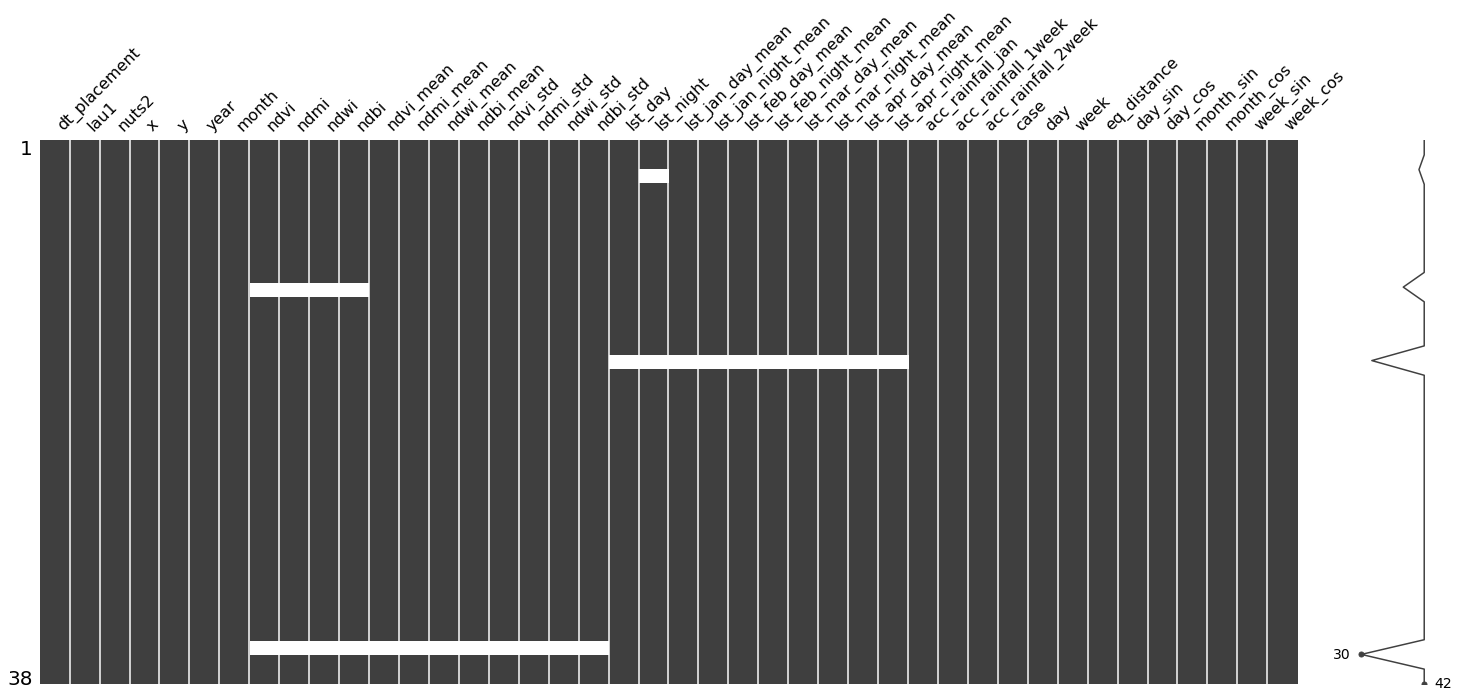

In [29]:
missingno.matrix(dataset)

In [30]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_WEB_Demographics_Processed.csv', encoding = enc)

In [31]:
df_demographics

,lau1,nuts2,nuts3,area,population_density,population
0,αβδηρων,ανατολικης μακεδονιας και θρακης,ξανθης,352.0,54.0,17860.0
1,αγαθονησιου,νοτιου αιγαιου,καλυμνου,14.5,12.8,203.0
2,αγιας,θεσσαλιας,λαρισας,661.8,17.3,10705.0
3,αγιας βαρβαρας,αττικης,δυτικου τομεα αθηνων,2.4,10925.9,26759.0
4,αγιας παρασκευης,αττικης,βορειου τομεα αθηνων,7.9,7557.5,62157.0
...,...,...,...,...,...,...
327,χανιων,κρητης,χανιων,351.3,309.3,110646.0
328,χερσονησου,κρητης,ηρακλειου,272.2,98.2,27229.0
329,χιου,βορειου αιγαιου,χιου,842.3,61.0,50483.0
330,ωραιοκαστρου,κεντρικης μακεδονιας,θεσσαλονικης,217.9,175.8,40114.0


In [32]:
df_demographics_nuts2 = df_demographics.query(f"nuts2 == '{NUTS2_EL}'").copy()

In [33]:
df_demographics_nuts2.drop(columns=['nuts2', 'nuts3'], inplace=True)
df_demographics_nuts2.reset_index(inplace=True, drop=True)

In [34]:
df_demographics_nuts2

,lau1,area,population_density,population
0,αλεξανδρειας,478.8,86.8,38293.0
1,αλμωπιας,985.8,28.0,24924.0
2,αμπελοκηπων μενεμενης,9.8,5319.1,49674.0
3,αμφιπολης,411.8,22.3,7169.0
4,αριστοτελη,747.0,24.5,16994.0
...,...,...,...,...
33,σιθωνιας,516.8,24.0,11631.0
34,σιντικης,1103.4,20.1,18532.0
35,σκυδρας,239.5,84.3,18080.0
36,χαλκηδονος,391.5,86.0,29951.0


In [35]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

['ναουσας']

Length: 1


In [36]:
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('ηρωικης πολεως ναουσας','ναουσας'))


In [37]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [38]:
dataset = pd.merge(dataset, df_demographics_nuts2,  how='left', on=['lau1'])

<AxesSubplot:>

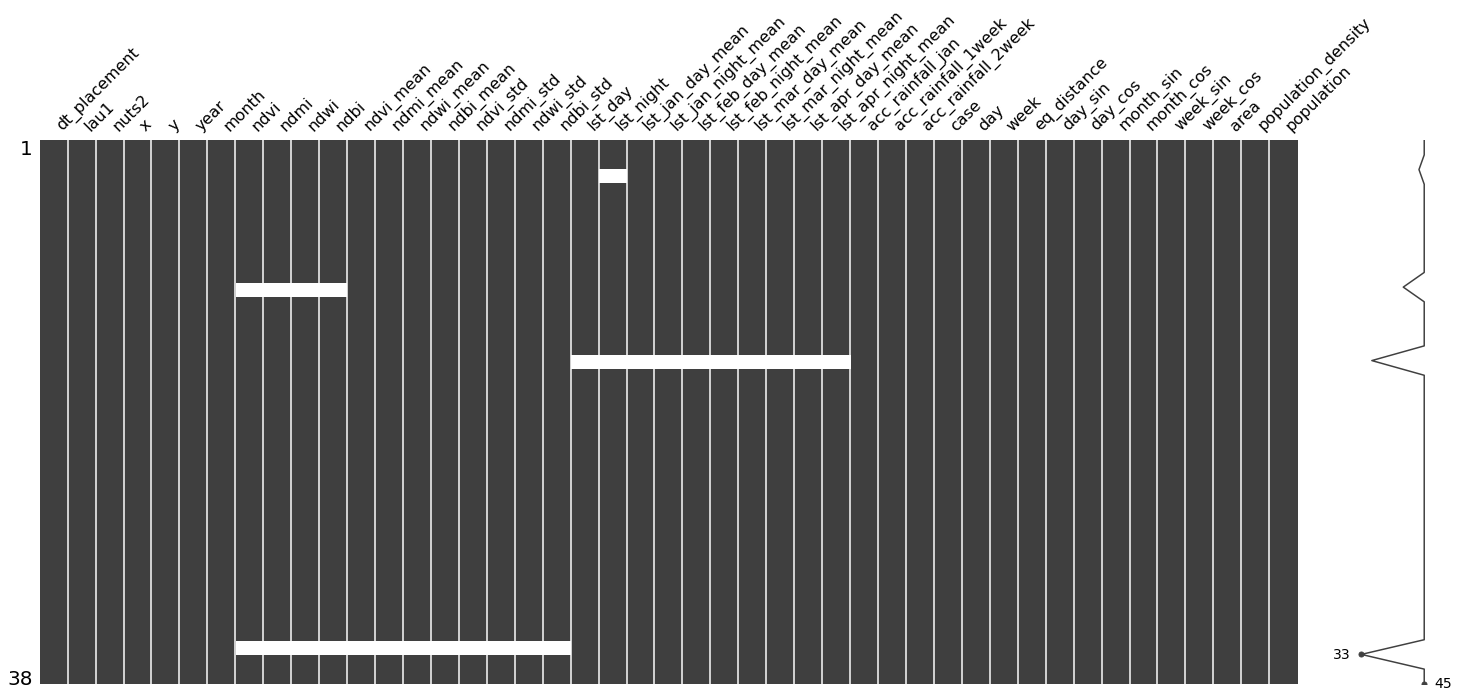

In [39]:
missingno.matrix(dataset)

In [40]:
missing = describe_dataframe(dataset)

In [41]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population_density,population
0,2023-06-16,αλεξανδρειας,κεντρικης μακεδονιας,22.48398,40.64468,2023,6,0.262609,-0.026801,-0.280632,0.026801,0.219906,-0.059068,-0.249076,0.059068,0.050410,0.036750,0.038178,0.036750,15609.500000,14603.666667,14234.189015,13749.690018,14263.884659,13680.811275,14767.111038,13922.951840,14921.198485,14052.387626,123.002828,3.634960,12.767325,0,16,24,46.44911,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401,478.8,86.8,38293.0
1,2023-06-16,αλμωπιας,κεντρικης μακεδονιας,21.94079,40.97703,2023,6,0.525521,0.260687,-0.404507,-0.260687,0.555146,0.286285,-0.424965,-0.286285,0.086064,0.060136,0.060803,0.060136,14797.636364,14291.000000,14057.777305,13785.095521,14049.086598,13664.427816,14324.249349,13852.660376,14396.198124,13956.128788,298.595070,21.183907,40.676157,0,16,24,46.48134,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401,985.8,28.0,24924.0
2,2023-06-16,αμπελοκηπων μενεμενης,κεντρικης μακεδονιας,22.89198,40.65603,2023,6,0.130873,-0.012212,-0.148510,0.012212,0.160420,-0.004443,-0.176910,0.004443,0.048214,0.013890,0.044105,0.013890,15483.000000,NaN,14276.571429,13837.333333,14251.000000,13783.769231,14595.538462,13913.571429,14852.400000,14251.000000,260.524000,1.075646,8.632042,0,16,24,46.65786,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401,9.8,5319.1,49674.0
3,2023-06-16,αμφιπολης,κεντρικης μακεδονιας,23.98253,40.91510,2023,6,0.598312,0.274682,-0.484040,-0.274682,0.566215,0.255534,-0.462863,-0.255534,0.048854,0.050004,0.032590,0.050004,15025.000000,14435.500000,14168.974242,13814.041667,14088.281801,13681.627828,14417.454762,13891.251136,14631.001389,13987.837500,110.863666,3.179120,4.742615,0,16,24,47.42581,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401,411.8,22.3,7169.0
4,2023-06-16,αριστοτελη,κεντρικης μακεδονιας,23.69108,40.49593,2023,6,0.698573,0.362266,-0.580013,-0.362266,0.692569,0.352810,-0.575431,-0.352810,0.026393,0.026033,0.019941,0.026033,14759.875000,14302.142857,14191.401297,13812.444494,14125.501096,13755.012945,14425.097837,13869.602156,14508.115950,14004.449082,249.626827,3.240275,5.731162,0,16,24,46.91682,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401,747.0,24.5,16994.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33,2023-06-16,σιθωνιας,κεντρικης μακεδονιας,23.82811,40.11026,2023,6,0.457736,0.124524,-0.384112,-0.124524,0.430542,0.118377,-0.360482,-0.118377,0.062081,0.051577,0.045394,0.051577,14997.000000,14449.200000,14299.930000,13928.119167,14169.179722,13820.954622,14426.578611,13938.588462,14594.725524,14073.681352,303.911073,0.588618,1.238375,0,16,24,46.65417,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401,516.8,24.0,11631.0
34,2023-06-16,σιντικης,κεντρικης μακεδονιας,23.38806,41.31348,2023,6,0.540334,0.213851,-0.456942,-0.213851,0.528988,0.237324,-0.441654,-0.237324,0.044199,0.040767,0.033907,0.040767,14849.818182,14249.100000,14191.712236,13762.496392,14075.517520,13650.563882,14416.621580,13838.663532,14529.864895,13943.706149,152.453347,10.358033,13.107569,0,16,24,47.47426,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401,1103.4,20.1,18532.0
35,2023-06-16,σκυδρας,κεντρικης μακεδονιας,22.14670,40.82294,2023,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15042.000000,14280.000000,14231.307692,13783.600000,14270.706478,13677.631250,14585.793956,13929.577778,14705.887500,14133.433333,187.853563,15.372839,20.547120,0,16,24,46.44339,-0.101168,-0

In [42]:
df_mosquitoes = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2023-{MONTH}-{PERIOD}.csv', encoding = enc)
df_mosquitoes

,x,y,dt_placement,mosq_pred
0,22.483978,40.644680,2023-06-16,246
1,21.940791,40.977027,2023-06-16,48
2,22.891980,40.656030,2023-06-16,396
3,23.982527,40.915103,2023-06-16,61
4,23.691080,40.495934,2023-06-16,58
...,...,...,...,...
33,23.828106,40.110264,2023-06-16,68
34,23.388058,41.313484,2023-06-16,59
35,22.146700,40.822940,2023-06-16,62
36,22.723020,40.753567,2023-06-16,408


In [43]:
df_mosquitoes['dt_placement'] = pd.to_datetime(dataset['dt_placement'])
df_mosquitoes['x'] = df_mosquitoes['x'].apply(lambda x : round(x,5))
df_mosquitoes['y'] = df_mosquitoes['y'].apply(lambda x : round(x,5))

In [44]:
distances, indicies = calculate_nearest_topological(dataset, df_mosquitoes)

In [45]:
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.0
Max distance: 0.0011119492658909769


In [46]:
df_mosq = pd.DataFrame(columns=df_mosquitoes.columns)

In [47]:
for index in indicies:
    df_mosq = df_mosq.append(df_mosquitoes.iloc[[index]])

df_mosq.drop(columns=['x', 'y', 'dt_placement'], inplace = True)
df_mosq.reset_index(drop=True, inplace=True)

In [48]:
dataset = pd.concat([dataset, df_mosq], axis=1, join = 'outer')

In [49]:
dataset.head()

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population_density,population,mosq_pred
0,2023-06-16,αλεξανδρειας,κεντρικης μακεδονιας,22.48398,40.64468,2023,6,0.262609,-0.026801,-0.280632,0.026801,0.219906,-0.059068,-0.249076,0.059068,0.050410,0.036750,0.038178,0.036750,15609.500000,14603.666667,14234.189015,13749.690018,14263.884659,13680.811275,14767.111038,13922.951840,14921.198485,14052.387626,123.002828,3.634960,12.767325,0,16,24,46.44911,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401,478.8,86.8,38293.0,246
1,2023-06-16,αλμωπιας,κεντρικης μακεδονιας,21.94079,40.97703,2023,6,0.525521,0.260687,-0.404507,-0.260687,0.555146,0.286285,-0.424965,-0.286285,0.086064,0.060136,0.060803,0.060136,14797.636364,14291.000000,14057.777305,13785.095521,14049.086598,13664.427816,14324.249349,13852.660376,14396.198124,13956.128788,298.595070,21.183907,40.676157,0,16,24,46.48134,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401,985.8,28.0,24924.0,48
2,2023-06-16,αμπελοκηπων μενεμενης,κεντρικης μακεδονιας,22.89198,40.65603,2023,6,0.130873,-0.012212,-0.148510,0.012212,0.160420,-0.004443,-0.176910,0.004443,0.048214,0.013890,0.044105,0.013890,15483.000000,NaN,14276.571429,13837.333333,14251.000000,13783.769231,14595.538462,13913.571429,14852.400000,14251.000000,260.524000,1.075646,8.632042,0,16,24,46.65786,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401,9.8,5319.1,49674.0,396
3,2023-06-16,αμφιπολης,κεντρικης μακεδονιας,23.98253,40.91510,2023,6,0.598312,0.274682,-0.484040,-0.274682,0.566215,0.255534,-0.462863,-0.255534,0.048854,0.050004,0.032590,0.050004,15025.000000,14435.500000,14168.974242,13814.041667,14088.281801,13681.627828,14417.454762,13891.251136,14631.001389,13987.837500,110.863666,3.179120,4.742615,0,16,24,47.42581,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401,411.8,22.3,7169.0,61
4,2023-06-16,αριστοτελη,κεντρικης μακεδονιας,23.69108,40.49593,2023,6,0.698573,0.362266,-0.580013,-0.362266,0.692569,0.352810,-0.575431,-0.352810,0.026393,0.026033,0.019941,0.026033,14759.875000,14302.142857,14191.401297,13812.444494,14125.501096,13755.012945,14425.097837,13869.602156,14508.115950,14004.449082,249.626827,3.240275,5.731162,0,16,24,46.91682,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401,747.0,24.5,16994.0,58


<AxesSubplot:>

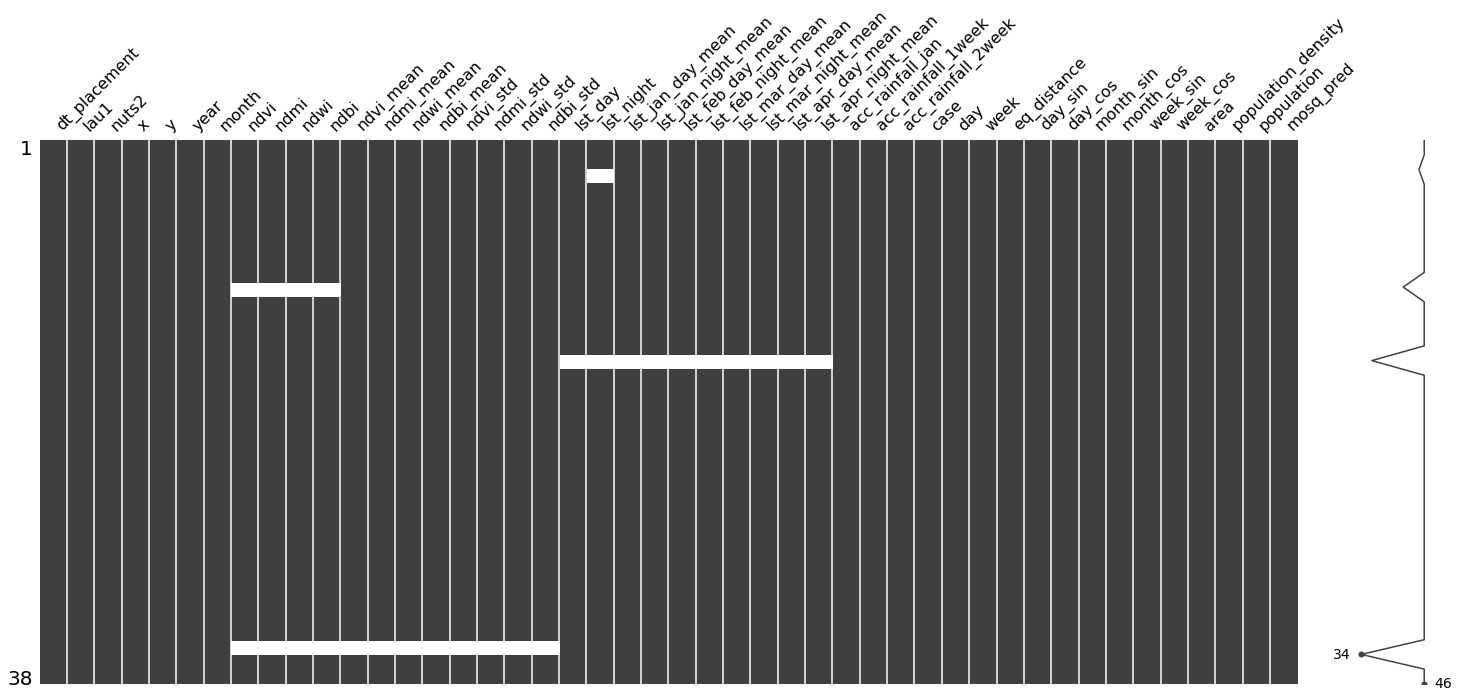

In [50]:
missingno.matrix(dataset)

In [51]:
dataset.reset_index(inplace=True, drop=True)

In [52]:
dataset = calculate_mosq_previous(dataset)

In [53]:
dataset = convert_temperature(dataset)

<AxesSubplot:>

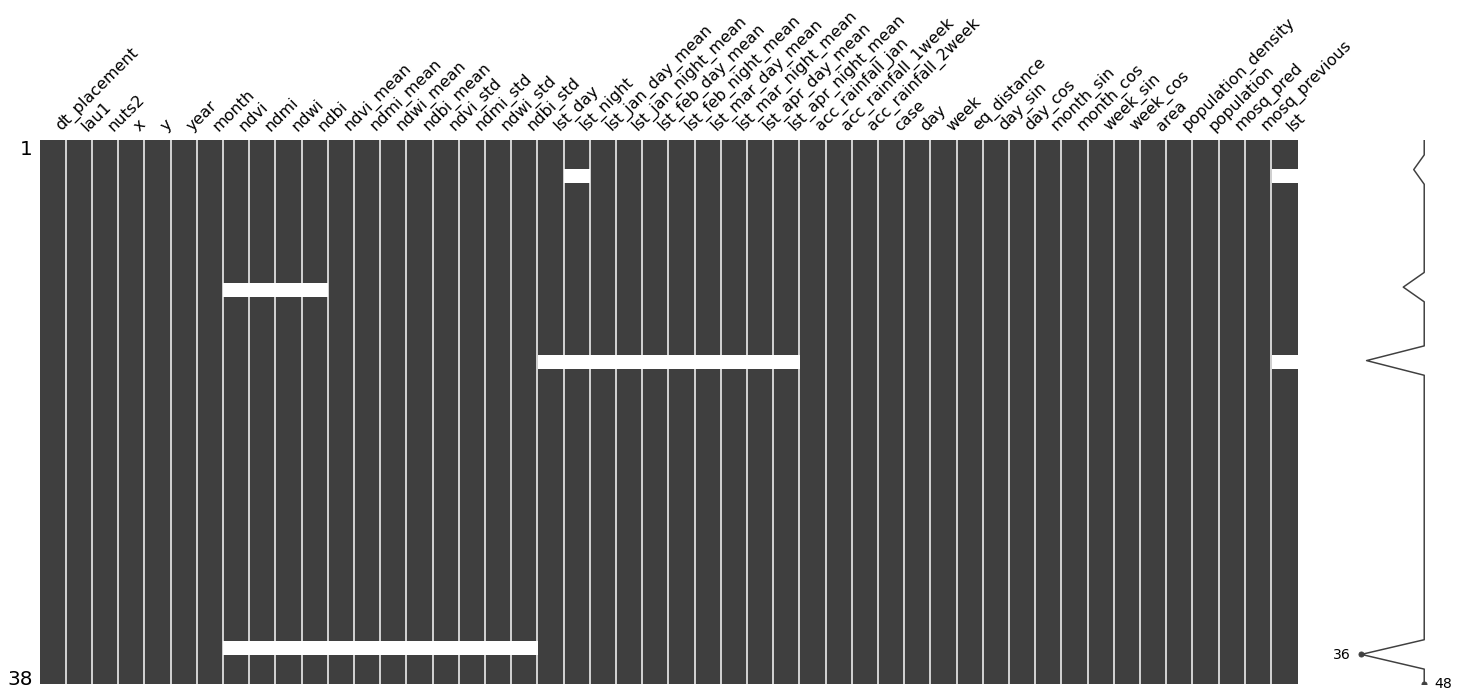

In [54]:
missingno.matrix(dataset)

In [55]:
dataset['case'].value_counts()

0    38
Name: case, dtype: int64

In [56]:
dataset = dataset.astype({'mosq_pred' : 'int', 'mosq_previous' : 'int'})

In [57]:
dataset = convert_multiple_cases(dataset)

In [58]:
dataset['case'].value_counts()

0    38
Name: case, dtype: int64

In [59]:
cols = dataset.columns

In [60]:
cols

Index(['dt_placement', 'lau1', 'nuts2', 'x', 'y', 'year', 'month', 'ndvi',
       'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_jan', 'acc_rainfall_1week', 'acc_rainfall_2week', 'case',
       'day', 'week', 'eq_distance', 'day_sin', 'day_cos', 'month_sin',
       'month_cos', 'week_sin', 'week_cos', 'area', 'population_density',
       'population', 'mosq_pred', 'mosq_previous', 'lst'],
      dtype='object')

In [61]:
len(cols)

48

In [62]:
# check columns

In [63]:
final_columns = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 
                 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 
                 'month_cos', 'week_sin', 'week_cos', 'area', 'population',
                 'population_density', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 
                 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 
                 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
                 'lst_day', 'lst_night','lst_jan_day_mean', 'lst_jan_night_mean', 
                 'lst_feb_day_mean','lst_feb_night_mean', 'lst_mar_day_mean', 
                 'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
                 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
                 'mosq_pred', 'mosq_previous', 'case']

In [64]:
len(final_columns)

48

In [65]:
dataset_final = dataset[final_columns].copy()

In [66]:
dataset_final

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,22.48398,40.64468,2023-06-16,κεντρικης μακεδονιας,αλεξανδρειας,16,6,24,2023,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401,478.8,38293.0,86.8,46.44911,0.262609,-0.026801,-0.280632,0.026801,0.219906,-0.059068,-0.249076,0.059068,0.050410,0.036750,0.038178,0.036750,28.981667,39.040000,18.923333,11.533780,1.843800,12.127693,0.466225,22.192221,5.309037,25.273970,7.897753,3.634960,12.767325,123.002828,246,0,0
1,21.94079,40.97703,2023-06-16,κεντρικης μακεδονιας,αλμωπιας,16,6,24,2023,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401,985.8,24924.0,28.0,46.48134,0.525521,0.260687,-0.404507,-0.260687,0.555146,0.286285,-0.424965,-0.286285,0.086064,0.060136,0.060803,0.060136,17.736364,22.802727,12.670000,8.005546,2.551910,7.831732,0.138556,13.334987,3.903208,14.773962,5.972576,21.183907,40.676157,298.595070,48,0,0
2,22.89198,40.65603,2023-06-16,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,16,6,24,2023,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401,9.8,49674.0,5319.1,46.65786,0.130873,-0.012212,-0.148510,0.012212,0.160420,-0.004443,-0.176910,0.004443,0.048214,0.013890,0.044105,0.013890,NaN,36.510000,NaN,12.381429,3.596667,11.870000,2.525385,18.760769,5.121429,23.898000,11.870000,1.075646,8.632042,260.524000,396,0,0
3,23.98253,40.91510,2023-06-16,κεντρικης μακεδονιας,αμφιπολης,16,6,24,2023,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401,411.8,7169.0,22.3,47.42581,0.598312,0.274682,-0.484040,-0.274682,0.566215,0.255534,-0.462863,-0.255534,0.048854,0.050004,0.032590,0.050004,21.455000,27.350000,15.560000,10.229485,3.130833,8.615636,0.482557,15.199095,4.675023,19.470028,6.606750,3.179120,4.742615,110.863666,61,0,0
4,23.69108,40.49593,2023-06-16,κεντρικης μακεδονιας,αριστοτελη,16,6,24,2023,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401,747.0,16994.0,24.5,46.91682,0.698573,0.362266,-0.580013,-0.362266,0.692569,0.352810,-0.575431,-0.352810,0.026393,0.026033,0.019941,0.026033,17.470179,22.047500,12.892857,10.678026,3.098890,9.360022,1.950259,15.351957,4.242043,17.012319,6.938982,3.240275,5.731162,249.626827,58,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33,23.82811,40.11026,2023-06-16,κεντρικης μακεδονιας,σιθωνιας,16,6,24,2023,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401,516.8,11631.0,24.0,46.65417,0.457736,0.124524,-0.384112,-0.124524,0.430542,0.118377,-0.360482,-0.118377,0.062081,0.051577,0.045394,0.051577,21.312000,26.790000,15.834000,12.848600,5.412383,10.233594,3.269092,15.381572,5.621769,18.744510,8.323627,0.588618,1.238375,303.911073,68,0,0
34,23.38806,41.31348,2023-06-16,κεντρικης μακεδονιας,σιντικης,16,6,24,2023,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401,1103.4,18532.0,20.1,47.47426,0.540334,0.213851,-0.456942,-0.213851,0.528988,0.237324,-0.441654,-0.237324,0.044199,0.040767,0.033907,0.040767,17.839182,23.846364,11.832000,10.684245,2.099928,8.360350,-0.138722,15.182432,3.623271,17.447298,5.724123,10.358033,13.107569,152.453347,59,0,0
35,22.14670,40.82294,2023-06-16,κεντρικης μακεδονιας,σκυδρας,16,6,24,2023,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401,239.5,18080.0,84.3,46.44339,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.070000,27.690000,12.450000,11.476154,2.522000,12.264130,0.402625,18.565879,5.441556,20.967750,9.518667,15.372839,20.547120,187.853563,62,0,0
36,22.72302,40.75357,2023-06-16,κεντρικης μακεδονιας

In [67]:
dataset_final.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2023-{MONTH}-{PERIOD}.csv", encoding = enc, index = False)